# ABC2Vec — Notebook 05: Pre-Training Pipeline

Full pre-training pipeline combining all components:

1. **Multi-objective training loop** — alternates between MMM, TI, and SCL objectives
2. **Learning rate scheduling** — warmup + cosine decay
3. **Gradient accumulation** — for effective larger batch sizes
4. **Validation monitoring** — track losses on held-out data
5. **Checkpointing** — save best models and resume training
6. **WandB logging** (optional) — experiment tracking

In [1]:
import os, sys, json, time, math, logging
from pathlib import Path
from datetime import datetime

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, ConcatDataset
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

PROJECT_DIR = Path('/Volumes/LLModels/ABC2VEC')
PROCESSED_DIR = PROJECT_DIR / 'data' / 'processed'
CHECKPOINT_DIR = PROJECT_DIR / 'checkpoints'
CHECKPOINT_DIR.mkdir(exist_ok=True)

sys.path.insert(0, str(PROJECT_DIR))
from abc2vec.tokenizer import ABCVocabulary, BarPatchifier, ABCTransposer, ABC2VecDataset, SectionPairDataset
from abc2vec.model import ABC2VecConfig, ABC2VecModel
from abc2vec.losses import ABC2VecLoss

# Setup logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')
logger = logging.getLogger('abc2vec')

In [2]:
# ─── Device setup ───
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"Using CUDA: {torch.cuda.get_device_name()}")
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
    print("Using Apple MPS")
else:
    device = torch.device('cpu')
    print("Using CPU")

print(f"Device: {device}")

Using Apple MPS
Device: mps


In [3]:
# ─── Load data & create datasets ───
vocab = ABCVocabulary.load(PROCESSED_DIR / 'vocab.json')
config = ABC2VecConfig.load(PROCESSED_DIR / 'model_config.json')
patchifier = BarPatchifier(vocab, max_bar_length=config.max_bar_length, max_bars=config.max_bars)

train_df = pd.read_parquet(PROCESSED_DIR / 'train.parquet')
val_df = pd.read_parquet(PROCESSED_DIR / 'val.parquet')

print(f"Train: {len(train_df):,} tunes")
print(f"Val:   {len(val_df):,} tunes")

# Main dataset (with transposition augmentation)
train_dataset = ABC2VecDataset(train_df, patchifier, augment_transpose=True)
val_dataset = ABC2VecDataset(val_df, patchifier, augment_transpose=True)

# Section pair dataset
section_pairs_path = PROCESSED_DIR / 'section_pairs.json'
if section_pairs_path.exists():
    section_dataset = SectionPairDataset(section_pairs_path, patchifier)
    print(f"Section pairs: {len(section_dataset):,}")
else:
    section_dataset = None
    print("No section pairs found — SCL will be skipped")

Train: 198,893 tunes
Val:   10,469 tunes
Section pairs: 302,005


## 5.1 Training Configuration

In [4]:
# ─── Hyperparameters ───
TRAIN_CONFIG = {
    # Batch sizes
    'batch_size': 32,
    'gradient_accumulation_steps': 4,  # Effective batch = 32 * 4 = 128
    
    # Optimizer
    'learning_rate': 1e-4,
    'weight_decay': 0.01,
    'adam_beta1': 0.9,
    'adam_beta2': 0.999,
    'adam_epsilon': 1e-8,
    'max_grad_norm': 1.0,
    
    # Schedule
    'num_epochs': 20,
    'warmup_steps': 1000,
    
    # Loss weights
    'lambda_mmm': 1.0,
    'lambda_scl': 0.5,
    'lambda_ti': 0.5,
    'lambda_vac': 0.5,
    
    # Logging & checkpointing
    'log_interval': 100,
    'eval_interval': 2000,
    'save_interval': 5000,
    'use_wandb': False,  # Set True for experiment tracking
    
    # Dataloader
    'num_workers': 4,
    'pin_memory': True,
}

print("Training configuration:")
for k, v in TRAIN_CONFIG.items():
    print(f"  {k}: {v}")

effective_batch = TRAIN_CONFIG['batch_size'] * TRAIN_CONFIG['gradient_accumulation_steps']
steps_per_epoch = len(train_dataset) // effective_batch
total_steps = steps_per_epoch * TRAIN_CONFIG['num_epochs']
print(f"\nEffective batch size: {effective_batch}")
print(f"Steps per epoch: {steps_per_epoch:,}")
print(f"Total steps: {total_steps:,}")

Training configuration:
  batch_size: 32
  gradient_accumulation_steps: 4
  learning_rate: 0.0001
  weight_decay: 0.01
  adam_beta1: 0.9
  adam_beta2: 0.999
  adam_epsilon: 1e-08
  max_grad_norm: 1.0
  num_epochs: 20
  warmup_steps: 1000
  lambda_mmm: 1.0
  lambda_scl: 0.5
  lambda_ti: 0.5
  lambda_vac: 0.5
  log_interval: 100
  eval_interval: 2000
  save_interval: 5000
  use_wandb: False
  num_workers: 4
  pin_memory: True

Effective batch size: 128
Steps per epoch: 1,553
Total steps: 31,060


In [5]:
# ─── Initialize model & optimizer ───
model = ABC2VecModel(config).to(device)
criterion = ABC2VecLoss(
    config,
    lambda_mmm=TRAIN_CONFIG['lambda_mmm'],
    lambda_scl=TRAIN_CONFIG['lambda_scl'],
    lambda_ti=TRAIN_CONFIG['lambda_ti'],
    lambda_vac=TRAIN_CONFIG['lambda_vac'],
)

optimizer = AdamW(
    model.parameters(),
    lr=TRAIN_CONFIG['learning_rate'],
    weight_decay=TRAIN_CONFIG['weight_decay'],
    betas=(TRAIN_CONFIG['adam_beta1'], TRAIN_CONFIG['adam_beta2']),
    eps=TRAIN_CONFIG['adam_epsilon'],
)

# LR schedule: linear warmup + cosine decay
warmup_scheduler = LinearLR(
    optimizer,
    start_factor=0.01,
    end_factor=1.0,
    total_iters=TRAIN_CONFIG['warmup_steps']
)
cosine_scheduler = CosineAnnealingLR(
    optimizer,
    T_max=total_steps - TRAIN_CONFIG['warmup_steps'],
    eta_min=1e-6,
)
scheduler = SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[TRAIN_CONFIG['warmup_steps']]
)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Optimizer: AdamW")
print(f"Schedule: Linear warmup ({TRAIN_CONFIG['warmup_steps']} steps) + Cosine decay")

Model parameters: 4,985,698
Optimizer: AdamW
Schedule: Linear warmup (1000 steps) + Cosine decay


In [6]:
# ─── Create DataLoaders ───
train_loader = DataLoader(
    train_dataset,
    batch_size=TRAIN_CONFIG['batch_size'],
    shuffle=True,
    num_workers=TRAIN_CONFIG['num_workers'],
    pin_memory=TRAIN_CONFIG['pin_memory'],
    drop_last=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=TRAIN_CONFIG['batch_size'],
    shuffle=False,
    num_workers=TRAIN_CONFIG['num_workers'],
    pin_memory=TRAIN_CONFIG['pin_memory'],
)

if section_dataset:
    section_loader = DataLoader(
        section_dataset,
        batch_size=TRAIN_CONFIG['batch_size'],
        shuffle=True,
        num_workers=TRAIN_CONFIG['num_workers'],
        pin_memory=TRAIN_CONFIG['pin_memory'],
        drop_last=True,
    )
    section_iter = iter(section_loader)
else:
    section_iter = None

print(f"Train loader: {len(train_loader)} batches")
print(f"Val loader: {len(val_loader)} batches")
if section_dataset:
    print(f"Section loader: {len(section_loader)} batches")

Train loader: 6215 batches
Val loader: 328 batches
Section loader: 9437 batches


## 5.2 Training Loop

In [7]:
def train_step(model, batch, section_batch, criterion, device):
    """
    Single training step combining MMM + TI + SCL objectives.
    """
    # Move batch to device
    bar_indices = batch['bar_indices'].to(device)
    char_mask = batch['char_mask'].to(device)
    bar_mask = batch['bar_mask'].to(device)
    
    # ─── Objective 1: MMM ───
    mmm_out = model.forward_mmm(bar_indices, char_mask, bar_mask)
    
    # ─── Objective 3: TI (transposition invariance) ───
    ti_emb_orig = None
    ti_emb_trans = None
    if 'trans_bar_indices' in batch:
        trans_bi = batch['trans_bar_indices'].to(device)
        trans_cm = batch['trans_char_mask'].to(device)
        trans_bm = batch['trans_bar_mask'].to(device)
        
        ti_emb_orig, ti_emb_trans = model.forward_contrastive(
            bar_indices, char_mask, bar_mask,
            trans_bi, trans_cm, trans_bm
        )
    
    # ─── Objective 2: SCL (section contrastive) ───
    scl_emb_a = None
    scl_emb_b = None
    if section_batch is not None:
        a_bi = section_batch['a_bar_indices'].to(device)
        a_cm = section_batch['a_char_mask'].to(device)
        a_bm = section_batch['a_bar_mask'].to(device)
        b_bi = section_batch['b_bar_indices'].to(device)
        b_cm = section_batch['b_char_mask'].to(device)
        b_bm = section_batch['b_bar_mask'].to(device)
        
        scl_emb_a, scl_emb_b = model.forward_contrastive(
            a_bi, a_cm, a_bm, b_bi, b_cm, b_bm
        )
    
    # ─── Combined loss ───
    total_loss, loss_dict = criterion(
        mmm_logits=mmm_out['mmm_logits'],
        mmm_targets=mmm_out['mmm_targets'],
        mmm_mask=mmm_out['mmm_mask'],
        scl_emb_a=scl_emb_a,
        scl_emb_b=scl_emb_b,
        ti_emb_orig=ti_emb_orig,
        ti_emb_trans=ti_emb_trans,
    )
    
    return total_loss, loss_dict


@torch.no_grad()
def validate(model, val_loader, criterion, device, max_batches=50):
    """Run validation and return average losses."""
    model.eval()
    all_losses = []
    
    for i, batch in enumerate(val_loader):
        if i >= max_batches:
            break
        
        bar_indices = batch['bar_indices'].to(device)
        char_mask = batch['char_mask'].to(device)
        bar_mask = batch['bar_mask'].to(device)
        
        # MMM objective only for validation
        mmm_out = model.forward_mmm(bar_indices, char_mask, bar_mask)
        
        # TI objective
        ti_orig = ti_trans = None
        if 'trans_bar_indices' in batch:
            ti_orig, ti_trans = model.forward_contrastive(
                bar_indices, char_mask, bar_mask,
                batch['trans_bar_indices'].to(device),
                batch['trans_char_mask'].to(device),
                batch['trans_bar_mask'].to(device),
            )
        
        _, loss_dict = criterion(
            mmm_logits=mmm_out['mmm_logits'],
            mmm_targets=mmm_out['mmm_targets'],
            mmm_mask=mmm_out['mmm_mask'],
            ti_emb_orig=ti_orig,
            ti_emb_trans=ti_trans,
        )
        all_losses.append(loss_dict)
    
    model.train()
    
    # Average losses
    avg_losses = {}
    for key in all_losses[0].keys():
        avg_losses[key] = np.mean([l[key] for l in all_losses])
    return avg_losses


def save_checkpoint(model, optimizer, scheduler, epoch, step, loss, path):
    """Save training checkpoint."""
    checkpoint = {
        'epoch': epoch,
        'step': step,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'loss': loss,
        'config': json.dumps(model.config.__dict__) if hasattr(model.config, '__dict__') else str(model.config),
    }
    torch.save(checkpoint, path)
    logger.info(f"Checkpoint saved: {path}")


print("Training functions defined.")

Training functions defined.


In [8]:
# ─── Optional: WandB initialization ───
if TRAIN_CONFIG['use_wandb']:
    import wandb
    wandb.init(
        project='abc2vec',
        config={**TRAIN_CONFIG, **config.__dict__},
        name=f'abc2vec-{datetime.now().strftime("%Y%m%d_%H%M")}',
    )
    print("WandB initialized")
else:
    print("WandB disabled — using local logging")

WandB disabled — using local logging


In [9]:

# ─── Resume from checkpoint (optional) ───
# Set RESUME_CHECKPOINT to a .pt file path to resume, or None to start fresh.
# Example: RESUME_CHECKPOINT = CHECKPOINT_DIR / 'best_model.pt'
#          RESUME_CHECKPOINT = CHECKPOINT_DIR / 'checkpoint_epoch7.pt'

# RESUME_CHECKPOINT = None  # <── change this to resume

RESUME_CHECKPOINT = CHECKPOINT_DIR / 'checkpoint_epoch11.pt'

start_epoch = 0
global_step = 0
best_val_loss = float('inf')

def load_checkpoint(path, model, optimizer, scheduler):
    """Load checkpoint and return (start_epoch, global_step, best_val_loss)."""
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    epoch      = ckpt['epoch']
    step       = ckpt['step']
    best_loss  = ckpt.get('loss', float('inf'))
    logger.info(f"Resumed from {path}  (epoch {epoch}, step {step}, loss {best_loss:.4f})")
    return epoch, step, best_loss

if RESUME_CHECKPOINT is not None:
    ckpt_path = Path(RESUME_CHECKPOINT)
    if ckpt_path.exists():
        start_epoch, global_step, best_val_loss = load_checkpoint(
            ckpt_path, model, optimizer, scheduler
        )
        # start_epoch is the *last completed* epoch, so resume from the next one
        start_epoch += 1
        print(f"Resuming from epoch {start_epoch}, step {global_step}")
    else:
        print(f"WARNING: checkpoint not found at {ckpt_path} — starting from scratch")
else:
    print("No checkpoint specified — starting from scratch (epoch 0)")


/var/folders/n6/wx4dvrnx75779kbnxd134__40000gn/T/ipykernel_36116/4114847666.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path, map_location=device)

Resuming from epoch 11, step 17083


In [10]:
# ═══════════════════════════════════════════════
#  MAIN TRAINING LOOP
# ═══════════════════════════════════════════════

model.train()
train_losses_history = []
val_losses_history = []

logger.info(f"Starting training for {TRAIN_CONFIG['num_epochs']} epochs")
logger.info(f"Total steps: {total_steps:,}")
if start_epoch > 0:
    logger.info(f"Resuming from epoch {start_epoch}, step {global_step}")

for epoch in range(start_epoch, TRAIN_CONFIG['num_epochs']):
    epoch_losses = []
    epoch_start = time.time()
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{TRAIN_CONFIG['num_epochs']}")
    
    for batch_idx, batch in enumerate(pbar):
        # Get section batch (if available)
        section_batch = None
        if section_iter is not None:
            try:
                section_batch = next(section_iter)
            except StopIteration:
                section_iter = iter(section_loader)
                section_batch = next(section_iter)
        
        # Forward + backward
        total_loss, loss_dict = train_step(model, batch, section_batch, criterion, device)
        
        # Scale loss for gradient accumulation
        scaled_loss = total_loss / TRAIN_CONFIG['gradient_accumulation_steps']
        scaled_loss.backward()
        
        # Optimizer step every gradient_accumulation_steps
        if (batch_idx + 1) % TRAIN_CONFIG['gradient_accumulation_steps'] == 0:
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), TRAIN_CONFIG['max_grad_norm'])
            
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            global_step += 1
        
        epoch_losses.append(loss_dict)
        
        # Update progress bar
        pbar.set_postfix({
            'loss': f"{loss_dict['total']:.3f}",
            'mmm': f"{loss_dict.get('mmm', 0):.3f}",
            'ti': f"{loss_dict.get('ti', 0):.3f}",
            'scl': f"{loss_dict.get('scl', 0):.3f}",
            'lr': f"{scheduler.get_last_lr()[0]:.2e}",
        })
        
        # Logging
        if global_step > 0 and global_step % TRAIN_CONFIG['log_interval'] == 0:
            avg_recent = {k: np.mean([l[k] for l in epoch_losses[-TRAIN_CONFIG['log_interval']:]]) 
                         for k in loss_dict.keys()}
            train_losses_history.append({'step': global_step, **avg_recent})
            
            if TRAIN_CONFIG['use_wandb']:
                import wandb
                wandb.log({f'train/{k}': v for k, v in avg_recent.items()}, step=global_step)
        
        # Validation
        if global_step > 0 and global_step % TRAIN_CONFIG['eval_interval'] == 0:
            val_losses = validate(model, val_loader, criterion, device)
            val_losses_history.append({'step': global_step, **val_losses})
            
            logger.info(f"Step {global_step}: Val loss = {val_losses['total']:.4f}")
            
            if TRAIN_CONFIG['use_wandb']:
                wandb.log({f'val/{k}': v for k, v in val_losses.items()}, step=global_step)
            
            # Save best model
            if val_losses['total'] < best_val_loss:
                best_val_loss = val_losses['total']
                save_checkpoint(
                    model, optimizer, scheduler, epoch, global_step,
                    best_val_loss, CHECKPOINT_DIR / 'best_model.pt'
                )
            
            model.train()
        
        # Periodic save
        if global_step > 0 and global_step % TRAIN_CONFIG['save_interval'] == 0:
            save_checkpoint(
                model, optimizer, scheduler, epoch, global_step,
                loss_dict['total'], CHECKPOINT_DIR / f'checkpoint_step{global_step}.pt'
            )
    
    # End of epoch
    epoch_time = time.time() - epoch_start
    avg_epoch_loss = np.mean([l['total'] for l in epoch_losses])
    logger.info(f"Epoch {epoch+1} complete: avg_loss={avg_epoch_loss:.4f}, time={epoch_time:.0f}s")
    
    # Save epoch checkpoint
    save_checkpoint(
        model, optimizer, scheduler, epoch, global_step,
        avg_epoch_loss, CHECKPOINT_DIR / f'checkpoint_epoch{epoch+1}.pt'
    )

# Final save
save_checkpoint(
    model, optimizer, scheduler, TRAIN_CONFIG['num_epochs'], global_step,
    avg_epoch_loss, CHECKPOINT_DIR / 'final_model.pt'
)
logger.info("Training complete!")

2026-03-17 10:59:55,374 [INFO] Starting training for 20 epochs
2026-03-17 10:59:55,375 [INFO] Total steps: 31,060
2026-03-17 10:59:55,375 [INFO] Resuming from epoch 11, step 17083


Epoch 12/20:   0%|          | 0/6215 [00:04<?, ?it/s]

2026-03-17 11:16:53,834 [INFO] Step 18000: Val loss = 2.4564
2026-03-17 11:16:54,906 [INFO] Checkpoint saved: /Volumes/LLModels/ABC2VEC/checkpoints/best_model.pt
2026-03-17 11:17:25,461 [INFO] Step 18000: Val loss = 2.4631
2026-03-17 11:17:56,297 [INFO] Step 18000: Val loss = 2.4419
2026-03-17 11:17:57,200 [INFO] Checkpoint saved: /Volumes/LLModels/ABC2VEC/checkpoints/best_model.pt
2026-03-17 11:18:27,866 [INFO] Step 18000: Val loss = 2.4483
2026-03-17 11:29:59,676 [INFO] Epoch 12 complete: avg_loss=2.6304, time=1804s
2026-03-17 11:30:00,561 [INFO] Checkpoint saved: /Volumes/LLModels/ABC2VEC/checkpoints/checkpoint_epoch12.pt


Epoch 13/20:   0%|          | 0/6215 [00:11<?, ?it/s]

2026-03-17 11:55:21,202 [INFO] Step 20000: Val loss = 2.4551
2026-03-17 11:55:22,153 [INFO] Checkpoint saved: /Volumes/LLModels/ABC2VEC/checkpoints/checkpoint_step20000.pt
2026-03-17 11:55:51,837 [INFO] Step 20000: Val loss = 2.4551
2026-03-17 11:55:52,424 [INFO] Checkpoint saved: /Volumes/LLModels/ABC2VEC/checkpoints/checkpoint_step20000.pt
2026-03-17 11:56:23,353 [INFO] Step 20000: Val loss = 2.4687
2026-03-17 11:56:23,982 [INFO] Checkpoint saved: /Volumes/LLModels/ABC2VEC/checkpoints/checkpoint_step20000.pt
2026-03-17 11:56:53,822 [INFO] Step 20000: Val loss = 2.4346
2026-03-17 11:56:54,540 [INFO] Checkpoint saved: /Volumes/LLModels/ABC2VEC/checkpoints/best_model.pt
2026-03-17 11:56:55,111 [INFO] Checkpoint saved: /Volumes/LLModels/ABC2VEC/checkpoints/checkpoint_step20000.pt
2026-03-17 12:00:35,063 [INFO] Epoch 13 complete: avg_loss=2.6198, time=1834s
2026-03-17 12:00:36,012 [INFO] Checkpoint saved: /Volumes/LLModels/ABC2VEC/checkpoints/checkpoint_epoch13.pt


...

2026-03-17 14:30:50,907 [INFO] Epoch 18 complete: avg_loss=2.5894, time=1902s
2026-03-17 14:30:51,970 [INFO] Checkpoint saved: /Volumes/LLModels/ABC2VEC/checkpoints/checkpoint_epoch18.pt


Epoch 19/20:   0%|          | 0/6215 [00:10<?, ?it/s]

2026-03-17 14:32:27,373 [INFO] Step 28000: Val loss = 2.4542
2026-03-17 14:32:57,150 [INFO] Step 28000: Val loss = 2.4376
2026-03-17 14:33:30,948 [INFO] Step 28000: Val loss = 2.4207
2026-03-17 14:34:01,586 [INFO] Step 28000: Val loss = 2.4358
2026-03-17 15:01:35,244 [INFO] Epoch 19 complete: avg_loss=2.5892, time=1843s
2026-03-17 15:01:36,277 [INFO] Checkpoint saved: /Volumes/LLModels/ABC2VEC/checkpoints/checkpoint_epoch19.pt


Epoch 20/20:   0%|          | 0/6215 [00:05<?, ?it/s]

2026-03-17 15:10:55,542 [INFO] Step 30000: Val loss = 2.4286
2026-03-17 15:10:56,591 [INFO] Checkpoint saved: /Volumes/LLModels/ABC2VEC/checkpoints/checkpoint_step30000.pt
2026-03-17 15:11:26,388 [INFO] Step 30000: Val loss = 2.4057
2026-03-17 15:11:27,217 [INFO] Checkpoint saved: /Volumes/LLModels/ABC2VEC/checkpoints/best_model.pt
2026-03-17 15:11:27,858 [INFO] Checkpoint saved: /Volumes/LLModels/ABC2VEC/checkpoints/checkpoint_step30000.pt
2026-03-17 15:11:57,827 [INFO] Step 30000: Val loss = 2.4291
2026-03-17 15:11:58,508 [INFO] Checkpoint saved: /Volumes/LLModels/ABC2VEC/checkpoints/checkpoint_step30000.pt
2026-03-17 15:12:28,625 [INFO] Step 30000: Val loss = 2.4305
2026-03-17 15:12:29,211 [INFO] Checkpoint saved: /Volumes/LLModels/ABC2VEC/checkpoints/checkpoint_step30000.pt
2026-03-17 15:31:36,681 [INFO] Epoch 20 complete: avg_loss=2.5892, time=1800s
2026-03-17 15:31:37,592 [INFO] Checkpoint saved: /Volumes/LLModels/ABC2VEC/checkpoints/checkpoint_epoch20.pt
2026-03-17 15:31:38,168 

## 5.3 Training Curves Visualization

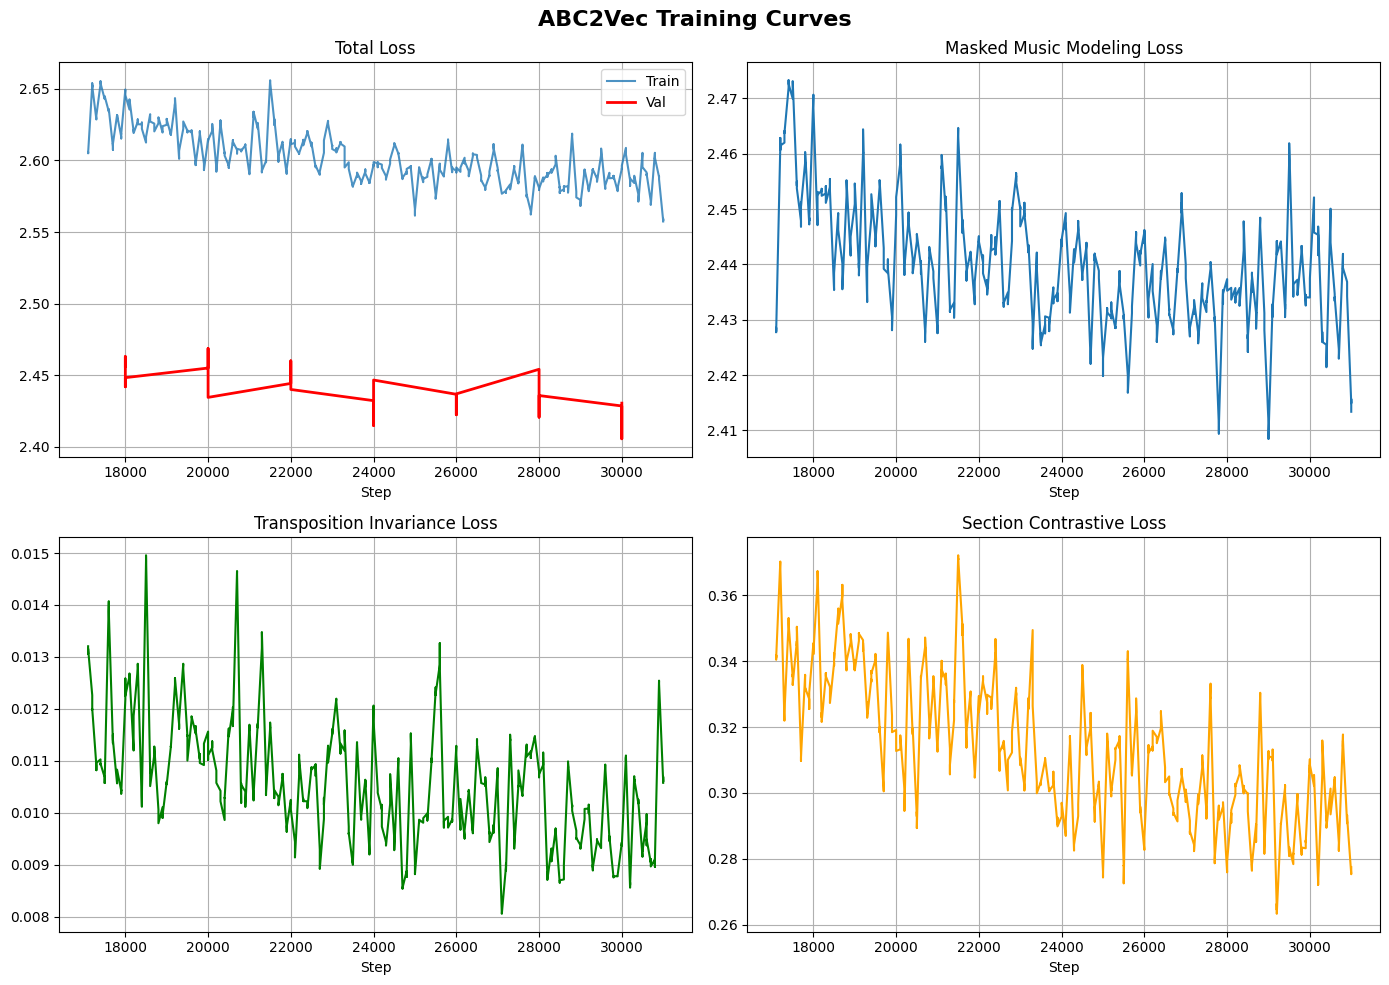

In [11]:
# ─── Plot training curves ───
if train_losses_history:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    train_steps = [l['step'] for l in train_losses_history]
    
    # Total loss
    axes[0, 0].plot(train_steps, [l['total'] for l in train_losses_history], label='Train', alpha=0.8)
    if val_losses_history:
        val_steps = [l['step'] for l in val_losses_history]
        axes[0, 0].plot(val_steps, [l['total'] for l in val_losses_history], 'r-', label='Val', linewidth=2)
    axes[0, 0].set_title('Total Loss')
    axes[0, 0].set_xlabel('Step')
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    
    # MMM loss
    if any('mmm' in l for l in train_losses_history):
        axes[0, 1].plot(train_steps, [l.get('mmm', 0) for l in train_losses_history], label='MMM')
        axes[0, 1].set_title('Masked Music Modeling Loss')
        axes[0, 1].set_xlabel('Step')
        axes[0, 1].grid(True)
    
    # TI loss
    if any('ti' in l for l in train_losses_history):
        axes[1, 0].plot(train_steps, [l.get('ti', 0) for l in train_losses_history], label='TI', color='green')
        axes[1, 0].set_title('Transposition Invariance Loss')
        axes[1, 0].set_xlabel('Step')
        axes[1, 0].grid(True)
    
    # SCL loss
    if any('scl' in l for l in train_losses_history):
        axes[1, 1].plot(train_steps, [l.get('scl', 0) for l in train_losses_history], label='SCL', color='orange')
        axes[1, 1].set_title('Section Contrastive Loss')
        axes[1, 1].set_xlabel('Step')
        axes[1, 1].grid(True)
    
    plt.suptitle('ABC2Vec Training Curves', fontsize=16, fontweight='bold')
    plt.tight_layout()
    Path(PROJECT_DIR / 'figures').mkdir(exist_ok=True)
    plt.savefig(PROJECT_DIR / 'figures' / 'training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No training history to plot yet.")

In [12]:
# ─── Save training history ───
history = {
    'train_losses': train_losses_history,
    'val_losses': val_losses_history,
    'config': TRAIN_CONFIG,
    'best_val_loss': best_val_loss,
    'total_steps': global_step,
}

history_path = CHECKPOINT_DIR / 'training_history.json'
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2, default=str)

print(f"Training history saved to {history_path}")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Total training steps: {global_step:,}")
print(f"\nCheckpoints saved:")
for ckpt in sorted(CHECKPOINT_DIR.glob('*.pt')):
    print(f"  {ckpt.name} ({ckpt.stat().st_size / 1e6:.1f} MB)")

Training history saved to /Volumes/LLModels/ABC2VEC/checkpoints/training_history.json
Best validation loss: 2.4057
Total training steps: 31,060

Checkpoints saved:
  best_model.pt (59.9 MB)
  checkpoint_epoch1.pt (59.9 MB)
  checkpoint_epoch10.pt (59.9 MB)
  checkpoint_epoch11.pt (59.9 MB)
  checkpoint_epoch12.pt (59.9 MB)
  checkpoint_epoch13.pt (59.9 MB)
  checkpoint_epoch14.pt (59.9 MB)
  checkpoint_epoch15.pt (59.9 MB)
  checkpoint_epoch16.pt (59.9 MB)
  checkpoint_epoch17.pt (59.9 MB)
  checkpoint_epoch18.pt (59.9 MB)
  checkpoint_epoch19.pt (59.9 MB)
  checkpoint_epoch2.pt (59.9 MB)
  checkpoint_epoch20.pt (59.9 MB)
  checkpoint_epoch3.pt (59.9 MB)
  checkpoint_epoch4.pt (59.9 MB)
  checkpoint_epoch5.pt (59.9 MB)
  checkpoint_epoch6.pt (59.9 MB)
  checkpoint_epoch7.pt (59.9 MB)
  checkpoint_epoch8.pt (59.9 MB)
  checkpoint_epoch9.pt (59.9 MB)
  checkpoint_step10000.pt (59.9 MB)
  checkpoint_step15000.pt (59.9 MB)
  checkpoint_step20000.pt (59.9 MB)
  checkpoint_step25000.pt (59.9